In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
from datetime import timedelta
from pathlib import Path
from src.utils import *
import os

In [3]:
glofas_reforecast_file_path = (
    Path(os.getenv("AA_DATA_DIR"))
    / "public"
    / "processed"
    / "npl"
    / "glofas"
    / "npl_cems-glofas-reforecast_v4.nc"
)
glofas_reforecast_data = xr.open_dataset(glofas_reforecast_file_path)
glofas_reforecast_data

C:\Users\pauni\AppData\Local\Temp\ipykernel_29112\3522286659.py:9: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  glofas_reforecast_data = xr.open_dataset(glofas_reforecast_file_path)


<xarray.Dataset> Size: 3MB
Dimensions:    (number: 11, time: 2195, leadtime: 10)
Coordinates:
  * number     (number) int32 44B 0 1 2 3 4 5 6 7 8 9 10
  * time       (time) datetime64[ns] 18kB 2003-03-27 2003-03-30 ... 2023-04-11
Dimensions without coordinates: leadtime
Data variables:
    Rai_Goan   (number, time, leadtime) float32 966kB ...
    Chatara    (number, time, leadtime) float32 966kB ...
    Chisapani  (number, time, leadtime) float32 966kB ...
    step       (leadtime) timedelta64[ns] 80B ...

In [9]:
# using RP from the online dashboard
# https://global-flood.emergency.copernicus.eu/glofas-forecasting/
chatara_rp_2 = 8113
chatara_rp_5 = 10306
chisapani_rp_2 = 5664
chisapani_rp_5 = 6797
raigoan_rp_2 = 2690
raigoan_rp_5 = 4222
readiness_leadtime = 7
action_leadtime = 3

In [10]:
# step is the number of days after the initial date
# number is the ensemble member number

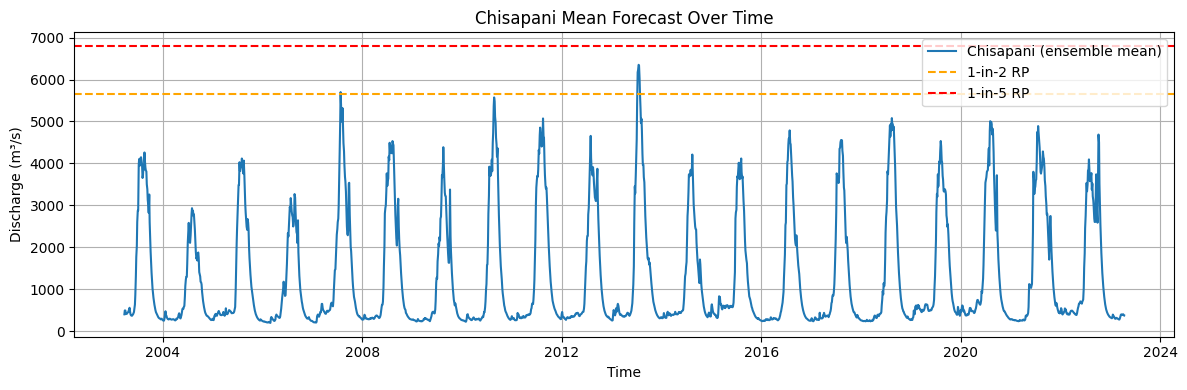

In [ ]:
# sense-checking the data
mean_series = glofas_reforecast_data["Chisapani"].mean(
    dim=["number", "leadtime"]
)
plt.figure(figsize=(12, 4))
plt.plot(
    glofas_reforecast_data["time"],
    mean_series,
    label="Chisapani (ensemble mean)",
)
plt.axhline(chisapani_rp_2, color="orange", linestyle="--", label="1-in-2 RP")
plt.axhline(chisapani_rp_5, color="red", linestyle="--", label="1-in-5 RP")
plt.xlabel("Time")
plt.ylabel("Discharge (m³/s)")
plt.title("Chisapani Mean Forecast Over Time")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def plot_exceedance_percent(ds, station, threshold, rp, max_leadtime):
    # Boolean array where values exceed the threshold
    exceedances = ds[station] > threshold

    # Max across leadtimes within 3/7 days (axis=-1), then mean over ensemble members (axis=0)
    percent_exceeding = (
        exceedances[:, :, :max_leadtime].any(dim="leadtime").mean(dim="number")
        * 100
    )

    # Plot
    plt.figure(figsize=(12, 4))
    plt.plot(
        ds["time"], percent_exceeding, label=f"% of members > 1-in-{rp} RP"
    )
    plt.axhline(70, color="gray", linestyle="--", label="70% reference")
    plt.xlabel("Time")
    plt.ylabel("Percent of Ensemble Members")
    plt.title(f"{station}: % of Ensemble Members Exceeding 1-in-{rp} RP")
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

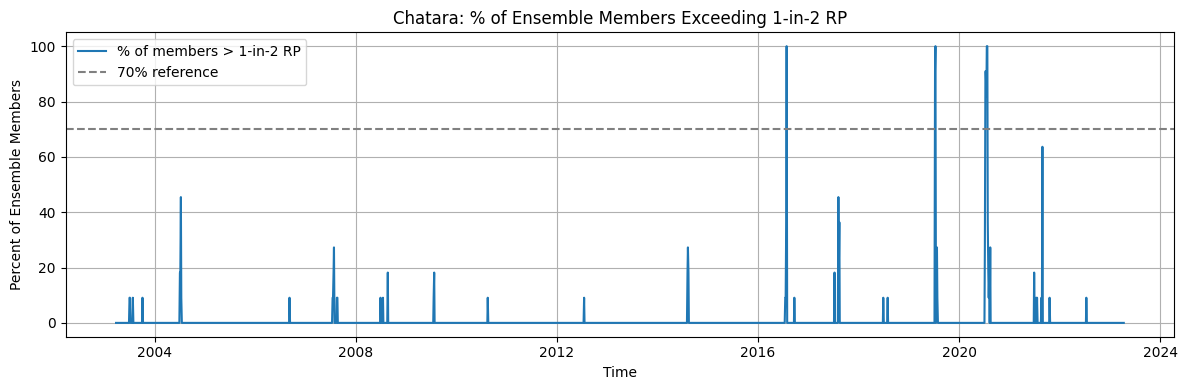

In [51]:
plot_exceedance_percent(glofas_reforecast_data, "Chatara", chatara_rp_2, 2, 7)

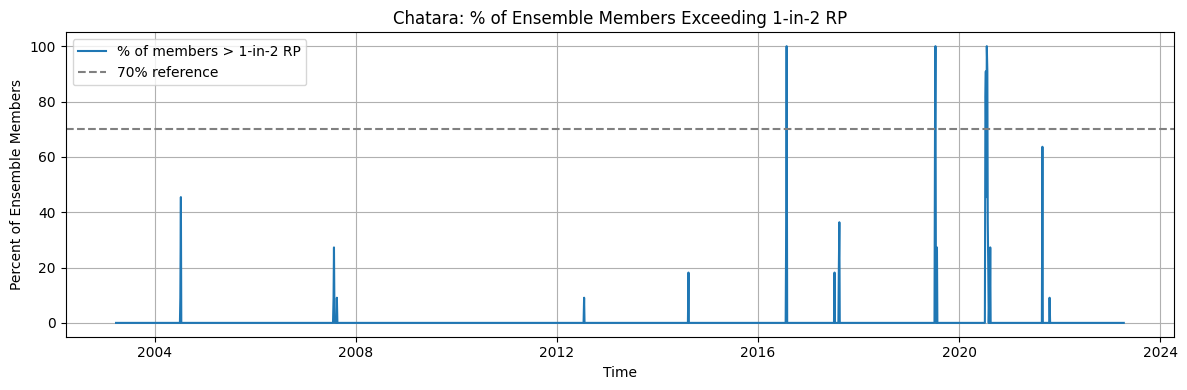

In [ ]:
plot_exceedance_percent(glofas_reforecast_data, "Chatara", chatara_rp_2, 2, 3)

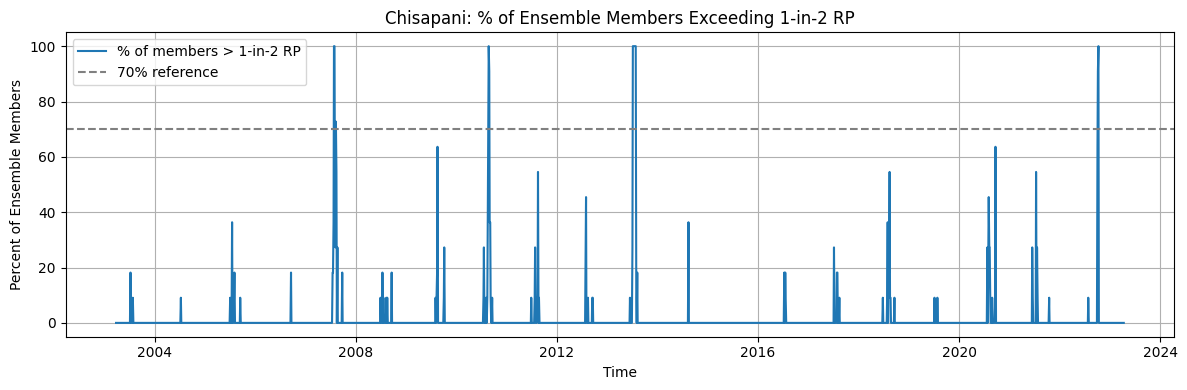

In [ ]:
plot_exceedance_percent(glofas_reforecast_data, "Chisapani", chisapani_rp_2, 2, 7)

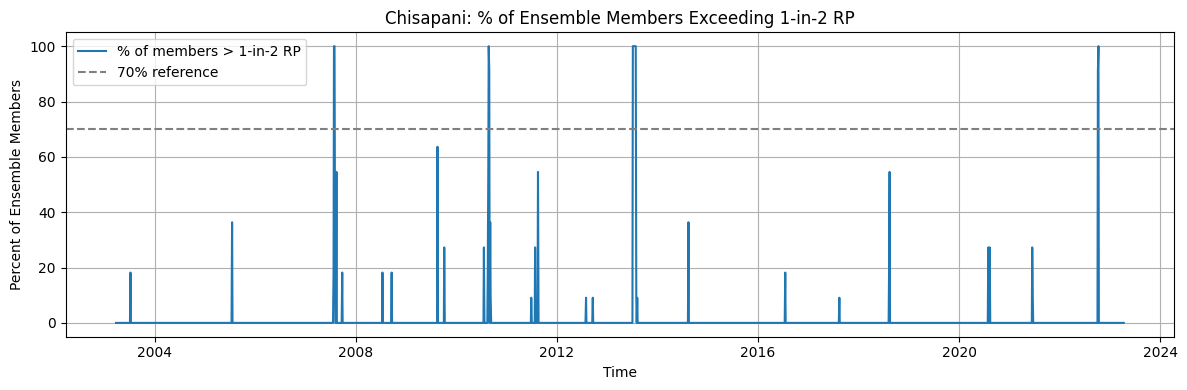

In [ ]:
plot_exceedance_percent(glofas_reforecast_data, "Chisapani", chisapani_rp_2, 2, 3)

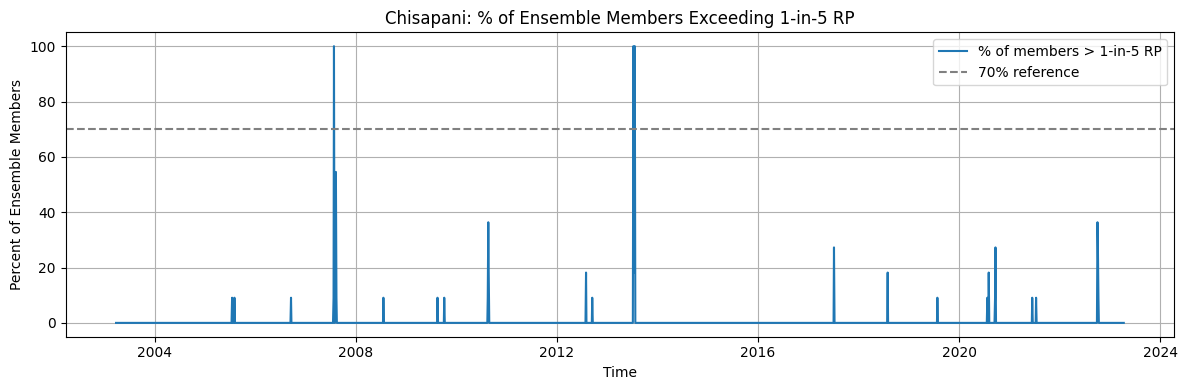

In [53]:
plot_exceedance_percent(
    glofas_reforecast_data, "Chisapani", chisapani_rp_5, 5, 7
)

In [96]:
# now looking at the return period based on the exceedance percent
def plot_exceedance_frequency_by_percent(
    ds, station, threshold, rp, max_leadtime
):
    exceedances = ds[station] > threshold  # shape: (number, time, leadtime)
    # number of years in the dataset
    n_years = ds.time.dt.year[-1].item() - ds.time.dt.year[0].item() + 1
    # Check if threshold exceeded within max_leadtime for each member
    event_within_time = exceedances[:, :, :max_leadtime].any(dim="leadtime")

    # Count % of members per time step
    percent_exceeding = (
        event_within_time.mean(dim="number") * 100
    )  # shape: (time,)

    # Count how many times each % bin (0–100) is met or exceeded
    # starting from 5% to 100% in increments of 5% as 0 shows all dates
    percent_bins = np.arange(5, 101, 10)
    crossing_counts = [
        (percent_exceeding >= p).sum().item() for p in percent_bins
    ]
    return_periods = n_years / np.array(crossing_counts)
    # Plot
    plt.figure(figsize=(8, 4))
    plt.plot(
        percent_bins,
        return_periods,
        marker="s",
    )

    # Highlight 1-in-3 to 1-in-5 region (20%–33%)
    # plt.axvspan(20, 33, color="gray", alpha=0.2, label="1-in-3 to 1-in-5 zone")

    plt.xlabel(f"% of Ensemble Members Exceeding 1-in-{rp} RP")
    plt.ylabel("Return Period (Years)")
    plt.title(
        f"{station}: Frequency of 1-in-{rp} RP Exceedance: {max_leadtime} Days"
    )
    plt.xticks(np.arange(0, 110, 10))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

C:\Users\pauni\AppData\Local\Temp\ipykernel_29112\771379405.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


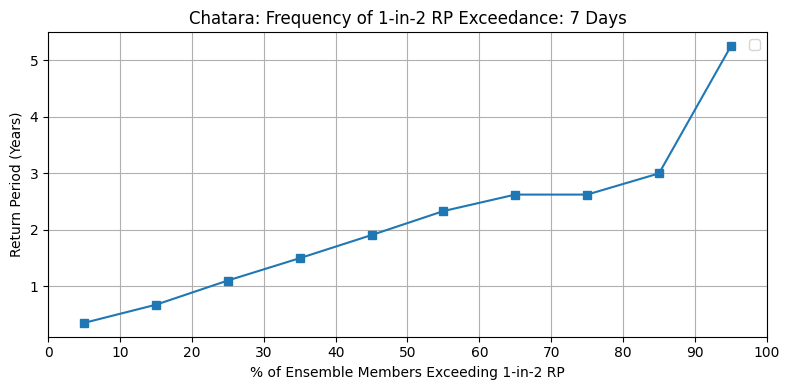

In [97]:
plot_exceedance_frequency_by_percent(
    glofas_reforecast_data,
    "Chatara",
    threshold=chatara_rp_2,
    rp=2,
    max_leadtime=7,
)

C:\Users\pauni\AppData\Local\Temp\ipykernel_29112\771379405.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


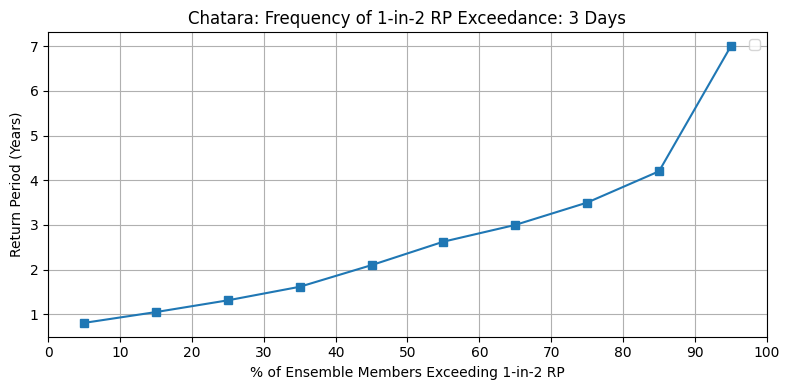

In [101]:
plot_exceedance_frequency_by_percent(
    glofas_reforecast_data,
    "Chatara",
    threshold=chatara_rp_2,
    rp=2,
    max_leadtime=3,
)

C:\Users\pauni\AppData\Local\Temp\ipykernel_29112\771379405.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


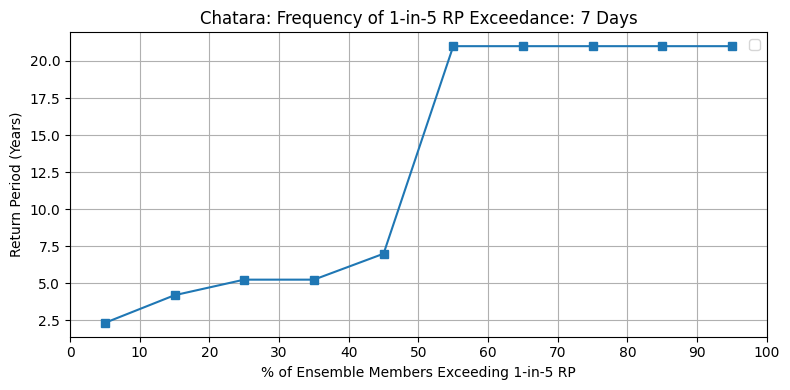

In [102]:
plot_exceedance_frequency_by_percent(
    glofas_reforecast_data,
    "Chatara",
    threshold=chatara_rp_5,
    rp=5,
    max_leadtime=7,
)

C:\Users\pauni\AppData\Local\Temp\ipykernel_29112\771379405.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


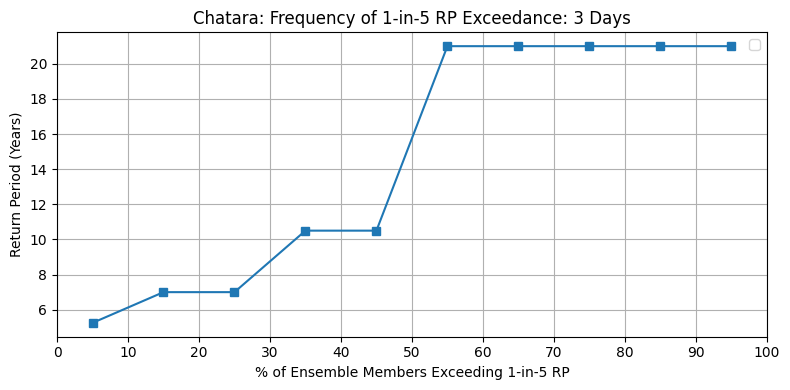

In [103]:
plot_exceedance_frequency_by_percent(
    glofas_reforecast_data,
    "Chatara",
    threshold=chatara_rp_5,
    rp=5,
    max_leadtime=3,
)